# Trabajo Final ICD 2026 - IBM HR Analytics

En este trabajo voy a predecir si un empleado abandona la empresa o no. Eso esta en la columna `Attrition`, que puede ser `Yes` (se fue) o `No` (se quedo).

Es un problema de clasificacion. Voy a usar dos modelos vistos en la materia: **Regresion Logistica** y **Random Forest**, y despues los comparo para ver cual anda mejor.

## 1. Cargar los datos

> En Google Colab hay que subir primero el archivo `IBM HR Analytics Employee_TF.csv` (boton de la carpeta, a la izquierda). El CSV usa `;` como separador.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
sns.set()
os.makedirs("figuras", exist_ok=True)

In [2]:
df = pd.read_csv("IBM HR Analytics Employee_TF.csv", sep=";")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# cuantas filas y columnas tiene
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1426 non-null   float64
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1397 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1323 non-null   float64
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1426.000000,1397.000000,1323.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.910940,803.877595,9.158730,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.161157,404.653518,8.104026,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,466.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1162.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 2. Exploracion de los datos

Antes de entrenar miro como son los datos: cuantos faltantes hay, como esta repartida la variable que quiero predecir y algunas relaciones.

In [6]:
# valores faltantes por columna (muestro las que tienen)
faltantes = df.isnull().sum()
faltantes[faltantes > 0]

Age                  44
DailyRate            73
DistanceFromHome    147
dtype: int64

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


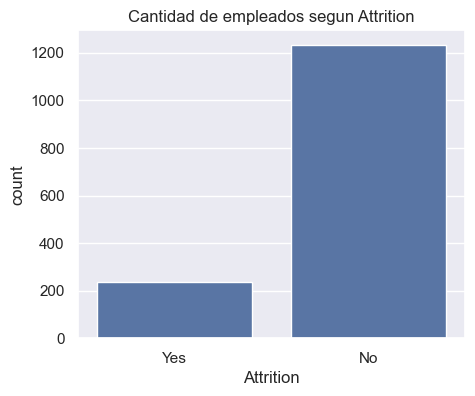

In [7]:
# como esta repartida la variable objetivo
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Cantidad de empleados segun Attrition")
plt.savefig("figuras/distribucion_attrition.png", bbox_inches="tight")
plt.show()

La mayoria de los empleados se queda (`No`). Solo alrededor del 16% se va. Hay que tenerlo en cuenta: un modelo podria tener accuracy alto simplemente diciendo siempre `No`.

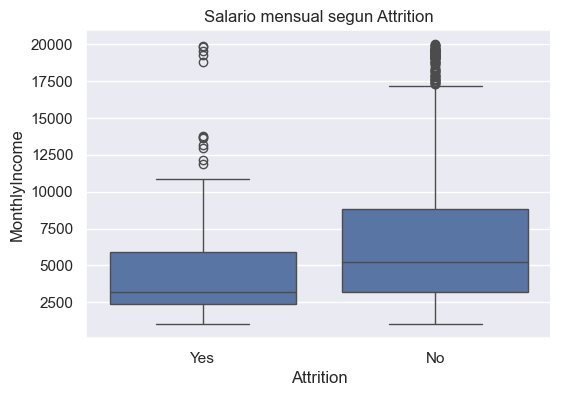

In [8]:
# Grafico de caja y bigotes (boxplot): salario segun si se fue o no
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Salario mensual segun Attrition")
plt.savefig("figuras/boxplot_salario.png", bbox_inches="tight")
plt.show()

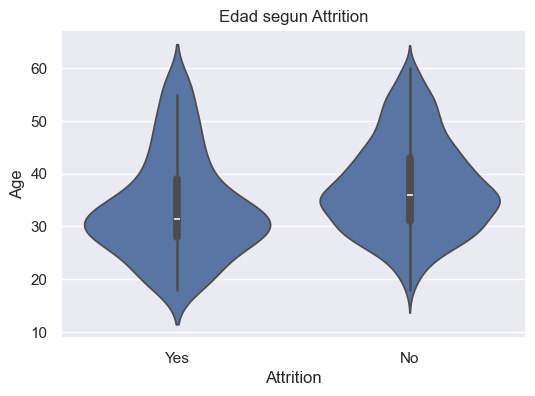

In [9]:
# Grafico de violin: edad segun si se fue o no
plt.figure(figsize=(6, 4))
sns.violinplot(x="Attrition", y="Age", data=df)
plt.title("Edad segun Attrition")
plt.savefig("figuras/violin_edad.png", bbox_inches="tight")
plt.show()

Attrition     No    Yes
OverTime               
No         0.896  0.104
Yes        0.695  0.305


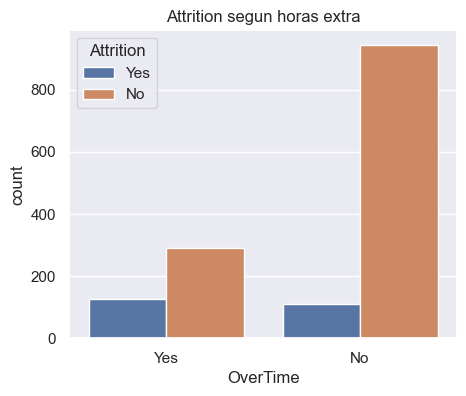

In [10]:
# Attrition segun si hace horas extra (OverTime)
print(pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition segun horas extra")
plt.savefig("figuras/rotacion_overtime.png", bbox_inches="tight")
plt.show()

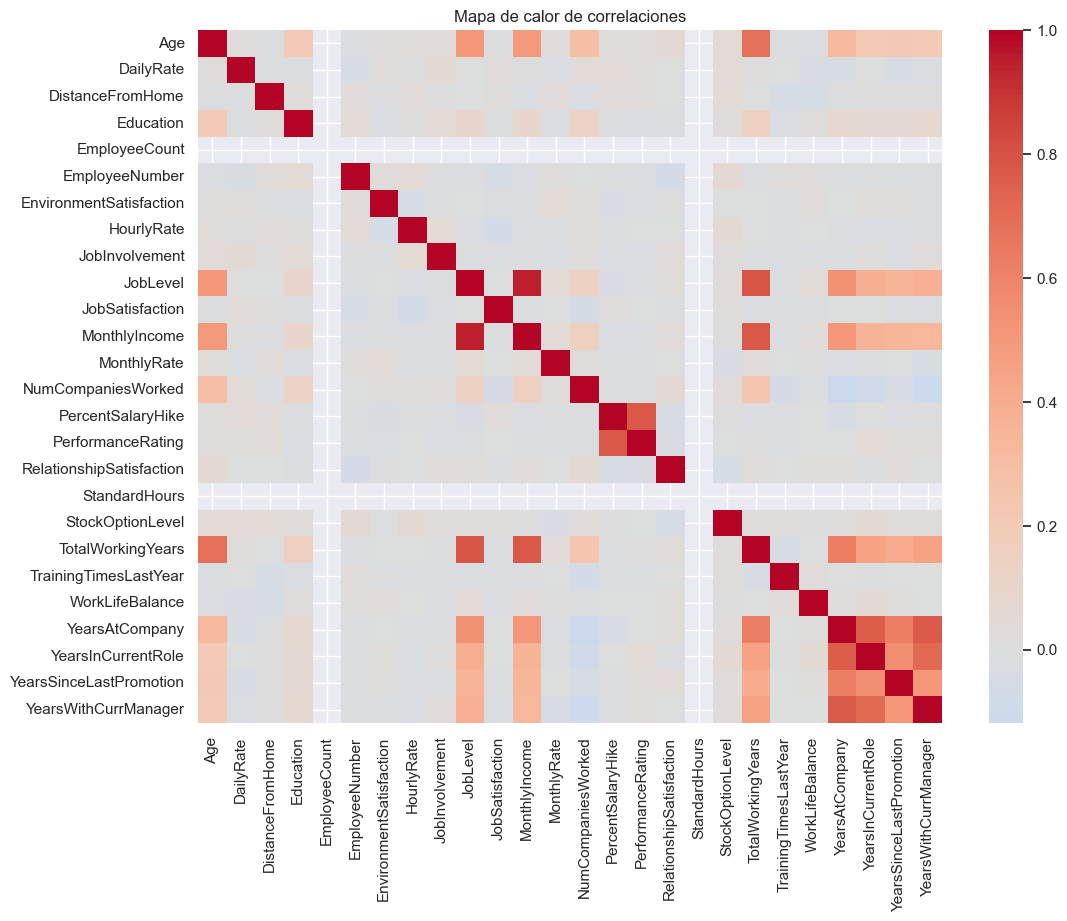

In [11]:
# Mapa de calor con las correlaciones de las variables numericas
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones")
plt.savefig("figuras/heatmap_correlaciones.png", bbox_inches="tight")
plt.show()

## 3. Limpieza y preparacion de los datos

Saco las columnas que no aportan, relleno los faltantes, paso `Attrition` a numero y convierto las variables de texto en numeros.

In [12]:
# Saco columnas que no sirven:
# EmployeeCount, StandardHours y Over18 tienen siempre el mismo valor.
# EmployeeNumber es solo un numero de legajo.
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

# Relleno los faltantes de las columnas numericas con la mediana
df = df.fillna(df.median(numeric_only=True))

# Paso la variable objetivo a numero: No = 0, Yes = 1
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

print("Faltantes que quedan:", df.isnull().sum().sum())

Faltantes que quedan: 0


In [13]:
# Separo las variables (X) de lo que quiero predecir (y)
# get_dummies convierte las columnas de texto en columnas 0/1
X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]

print("X quedo con", X.shape[1], "columnas")
columnas = X.columns  # las guardo para despues

# Divido en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalo las variables numericas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape[0], "filas  |  Test:", X_test.shape[0], "filas")

X quedo con 44 columnas
Train: 1176 filas  |  Test: 294 filas


## 4. Entrenar los modelos

In [14]:
# Modelo 1: Regresion Logistica
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Modelo 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("Modelos entrenados")

Modelos entrenados


## 5. Evaluacion

Para cada modelo miro el accuracy, el reporte de clasificacion y la matriz de confusion.

REGRESION LOGISTICA
Accuracy: 0.8605
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



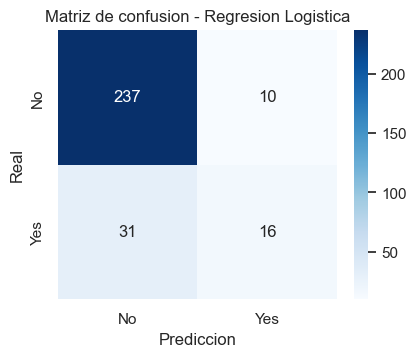

In [15]:
# Regresion Logistica
y_pred_log = log_reg.predict(X_test)

print("REGRESION LOGISTICA")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print(classification_report(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Matriz de confusion - Regresion Logistica")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.savefig("figuras/matriz_confusion_logistica.png", bbox_inches="tight")
plt.show()

RANDOM FOREST
Accuracy: 0.8401
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294



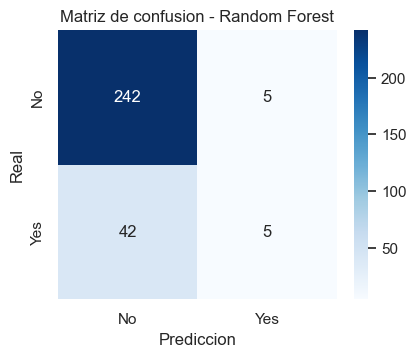

In [16]:
# Random Forest
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Matriz de confusion - Random Forest")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.savefig("figuras/matriz_confusion_random_forest.png", bbox_inches="tight")
plt.show()

## 6. Comparacion de los modelos

                 Regresion Logistica  Random Forest
Accuracy                      0.8605         0.8401
Precision (Yes)               0.6154         0.5000
Recall (Yes)                  0.3404         0.1064
F1 (Yes)                      0.4384         0.1754


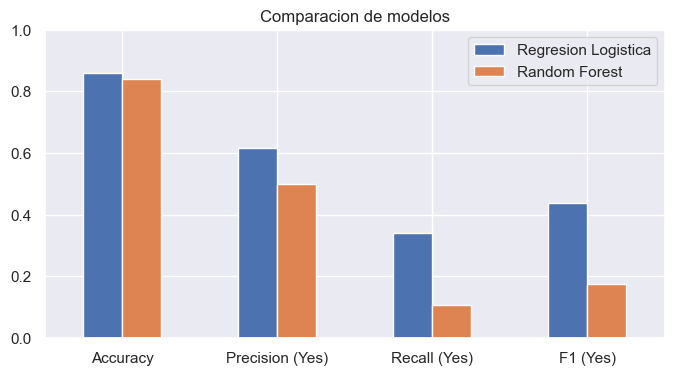

In [17]:
resultados = pd.DataFrame({
    "Regresion Logistica": [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
    ],
}, index=["Accuracy", "Precision (Yes)", "Recall (Yes)", "F1 (Yes)"]).round(4)

print(resultados)

resultados.plot(kind="bar", figsize=(8, 4))
plt.title("Comparacion de modelos")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.savefig("figuras/comparacion_modelos.png", bbox_inches="tight")
plt.show()

MonthlyIncome         0.068091
Age                   0.066000
TotalWorkingYears     0.057350
DailyRate             0.052594
DistanceFromHome      0.049405
HourlyRate            0.048084
MonthlyRate           0.045026
YearsAtCompany        0.043085
OverTime_Yes          0.036792
NumCompaniesWorked    0.036698
dtype: float64


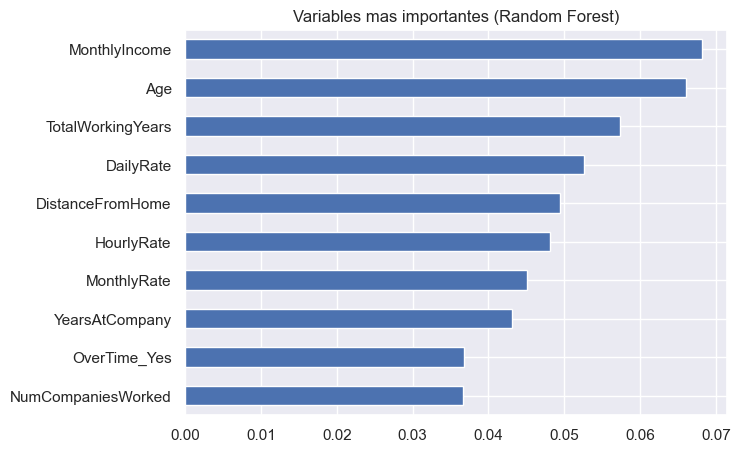

In [18]:
# Variables mas importantes segun el Random Forest
importancias = pd.Series(rf.feature_importances_, index=columnas).sort_values(ascending=False)
print(importancias.head(10))

plt.figure(figsize=(7, 5))
importancias.head(10).sort_values().plot(kind="barh")
plt.title("Variables mas importantes (Random Forest)")
plt.savefig("figuras/importancia_variables.png", bbox_inches="tight")
plt.show()

## 7. Conclusion

La **Regresion Logistica** anduvo mejor que el Random Forest en todas las metricas:
mas accuracy (0.86 contra 0.84) y, lo mas importante, mejor recall y F1 para la clase
`Yes`, que es la que interesa si la idea es anticipar quien se va a ir.

Igual, ningun modelo detecta del todo bien a los que renuncian. Eso pasa porque hay
pocos casos `Yes` (el dataset esta desbalanceado) y a los modelos les cuesta aprender
ese grupo. Conviene no quedarse solo con el accuracy: como la mayoria de los empleados
se queda, un accuracy alto puede confundir.

Como mejora se podria darle mas peso a la clase `Yes`, ajustar los parametros o usar
validacion cruzada.